In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("zomato.csv",encoding ="latin-1") #UTF-8 Encoding doesn't work so doing this

In [106]:
#Task 1 : Data Understanding
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Shape: (9551, 21)

Columns:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   ob

In [107]:
#Task 2 : Data Cleaning
df.drop_duplicates(inplace=True) #To remove duplicate data
print("\nMissing values after cleaning:")
print(df.isnull().sum())
df["Cuisines"] = df["Cuisines"].fillna("Unknown") #Filling NaN with Unknown


Missing values after cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [108]:
#Task 3 : Descriptive Statistics
numerical_cols = [
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]
#Made a list with the numerical columns so we can put them throught a loop instead of writing each time 
for col in numerical_cols:
    print(f"\n-----{col}-----")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std dev:", df[col].std())
    print("Variance:", df[col].var())


-----Longitude-----
Mean: 64.12657446168704
Median: 77.1919642
Mode: 0.0
Std dev: 41.467057847617575
Variance: 1719.5168865376622

-----Latitude-----
Mean: 25.854380700074756
Median: 28.57046888
Mode: 0.0
Std dev: 11.007935124784685
Variance: 121.17463571146843

-----Average Cost for two-----
Mean: 1199.2107632708617
Median: 400.0
Mode: 500
Std dev: 16121.18307349965
Variance: 259892543.6892916

-----Price range-----
Mean: 1.804837189823055
Median: 2.0
Mode: 1
Std dev: 0.9056088473975366
Variance: 0.8201273844846946

-----Aggregate rating-----
Mean: 2.6663700136111403
Median: 3.2
Mode: 0.0
Std dev: 1.5163775396521686
Variance: 2.2994008427615644

-----Votes-----
Mean: 156.909747670401
Median: 31.0
Mode: 0
Std dev: 430.1691453762977
Variance: 185045.49363377434


Mean and Median are almost same for Latitude, Price Range and Rating; this means that the data in those columns is pretty symmetric. The other columns have outliers .


City with highest restaurants:
New Delhi 5473

Top 10 cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64 




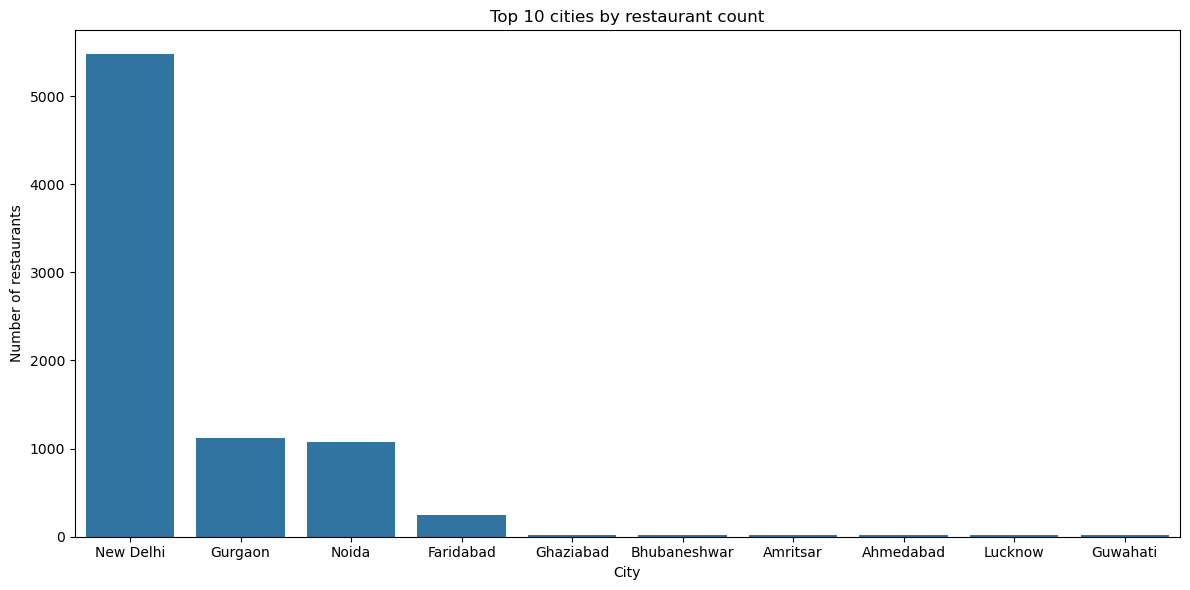

In [109]:
#Task 4: Restaurant Distribution Analysis
city_counts = df["City"].value_counts() #This creates a data with City as the index
print("\nCity with highest restaurants:")
print(city_counts.idxmax(), city_counts.max())
print("\nTop 10 cities:")
print(city_counts.head(10),"\n\n")
plt.figure(figsize=(12,6))
sns.barplot(data = city_counts.head(10))
plt.title("Top 10 cities by restaurant count")
plt.ylabel("Number of restaurants")
plt.tight_layout() #So that names don't merge into each other
plt.show()


Top 10 most common cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

Top 10 highest rated cuisines:
Cuisines
Sunda         4.900000
Bí_rek        4.700000
Taiwanese     4.650000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
Dí_ner        4.400000
Bubble Tea    4.400000
Curry         4.400000
Kebab         4.380000
Name: Aggregate rating, dtype: float64 




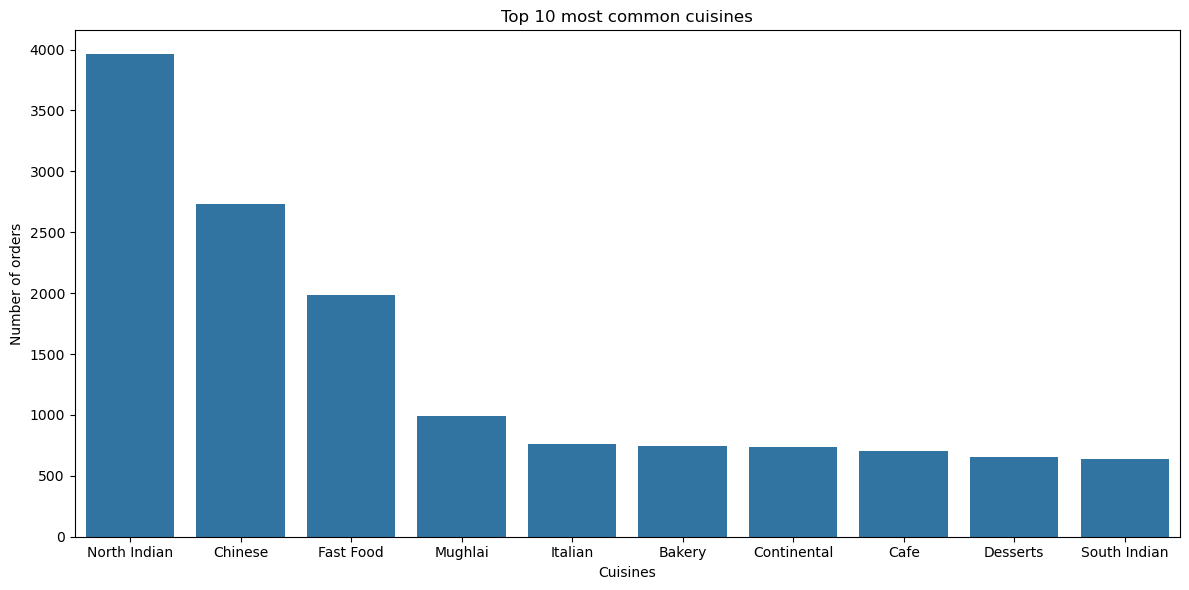

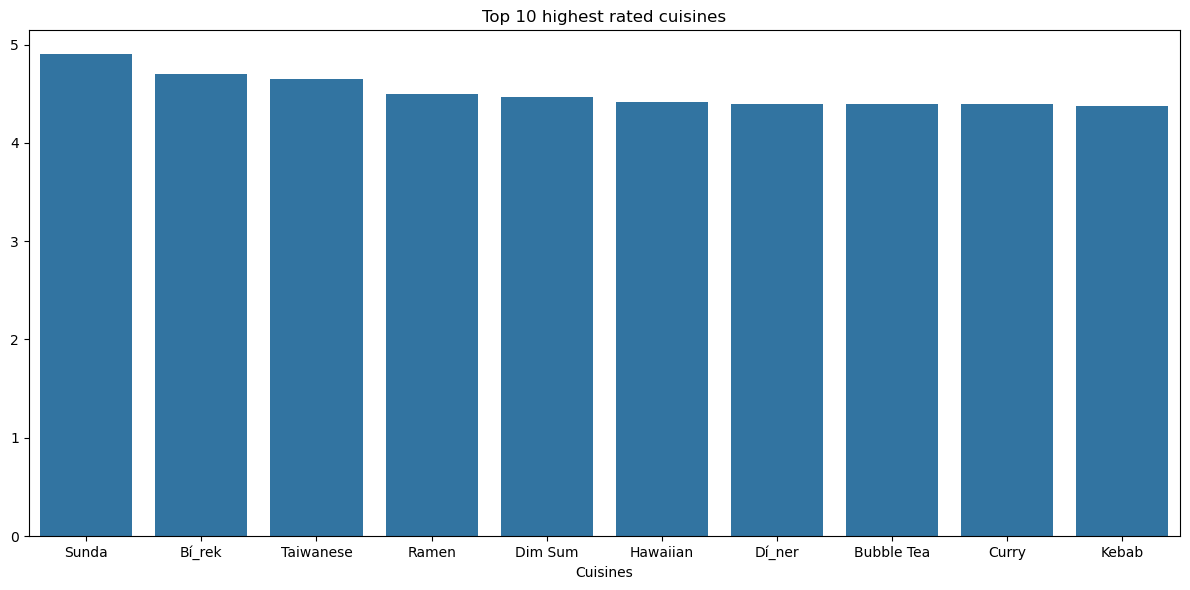

In [110]:
#Task 5: Cuisine Analysis
all_cuisines = (
    df["Cuisines"]
    .str.split(", ") #This converts all comma separated into list
    .explode() #This keeps the index of original row
)
top10_common = all_cuisines.value_counts().head(10)
print("\nTop 10 most common cuisines:")
print(top10_common)
cuisine_ratings = pd.merge(df["Aggregate rating"],all_cuisines,left_index=True,right_index=True,how="inner")
avg_ratings = cuisine_ratings.groupby("Cuisines")["Aggregate rating"].mean()
top10_rated = avg_ratings.sort_values(ascending=False).head(10)
print("\nTop 10 highest rated cuisines:")
print(top10_rated,"\n\n")

all_cuisines = df["Cuisines"].str.split(", ").explode().reset_index(drop=True) #Setting Index back to normal in order to plot
#Countplot for most common
plt.figure(figsize=(12,6))
sns.countplot(
    data=all_cuisines.to_frame(),
    x="Cuisines",
    order=all_cuisines.value_counts().head(10).index,
)
plt.title("Top 10 most common cuisines")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()
print()
#Barplot for highest rated
plt.figure(figsize=(12,6))
sns.barplot(
    x=top10_rated.index, 
    y=top10_rated.values
)
plt.title("Top 10 highest rated cuisines")
plt.ylabel("")
plt.tight_layout()
plt.show()


Rating distribution:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

Skewness:
-0.9541304733200121

Total outliers: 2148


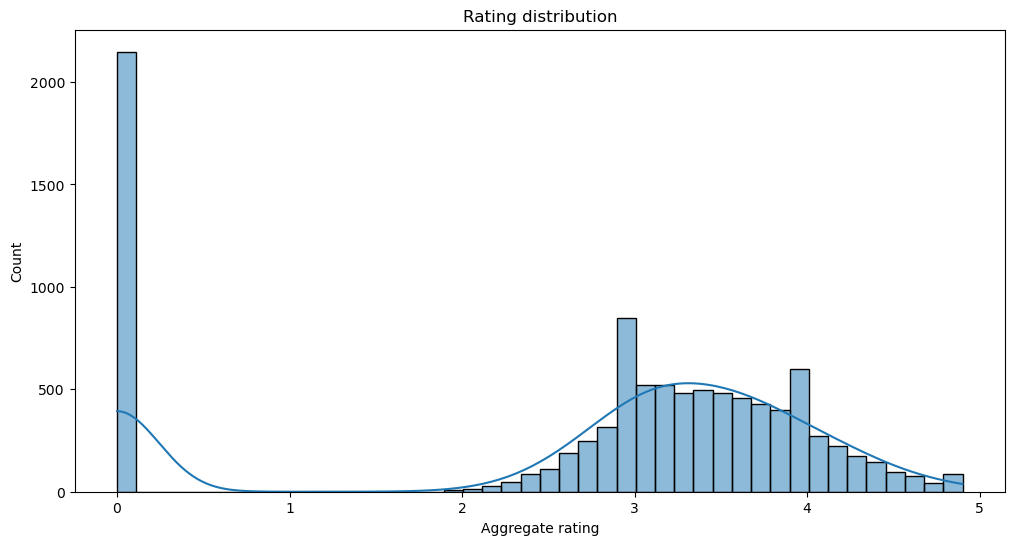

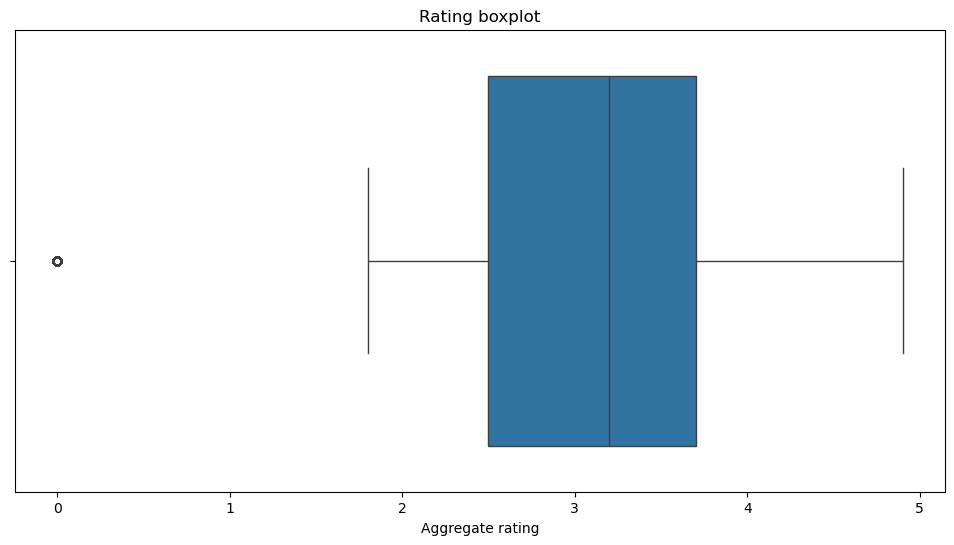

In [111]:
#Task 6: Rating Analysis
print("\nRating distribution:")
print(df["Aggregate rating"].describe())

print("\nSkewness:")
print(df["Aggregate rating"].skew())

Q1 = df["Aggregate rating"].quantile(0.25)
Q3 = df["Aggregate rating"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df["Aggregate rating"] < lower) |
    (df["Aggregate rating"] > upper)
]
print("\nTotal outliers:", len(outliers)) #Len used to find number of outliers, found for IQR (a process with relies on median over mean)

#Histogram
plt.figure(figsize=(12,6))
sns.histplot(df["Aggregate rating"], kde=True)
plt.title("Rating distribution")
plt.show()
print()
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x=df["Aggregate rating"])
plt.title("Rating boxplot")
plt.show()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Average Ratings
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64 




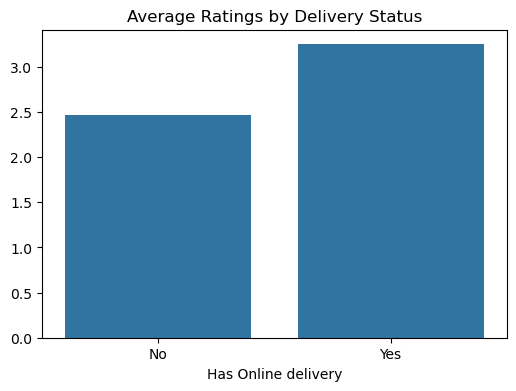

In [112]:
#Task 7: Online Delivery Analysis
delivery_counts = df["Has Online delivery"].value_counts()
print(delivery_counts)

avg_rating_delivery = (df.groupby("Has Online delivery")["Aggregate rating"].mean())
print("\nAverage Ratings")
print(avg_rating_delivery,"\n\n")
#Barplot
plt.figure(figsize=(6,4))
sns.barplot(
    x=avg_rating_delivery.index,
    y=avg_rating_delivery.values
)
plt.title("Average Ratings by Delivery Status")
plt.show()


Average cost:
1199.2107632708617

Most expensive restaurants
                  Restaurant Name       City  Average Cost for two
9284     Satoo - Hotel Shangri-La    Jakarta                800000
9283                         Skye    Jakarta                800000
9287                   Sushi Masa    Jakarta                500000
9289               3 Wise Monkeys    Jakarta                450000
9294  Avec Moi Restaurant and Bar    Jakarta                350000
9295                      Onokabe  Tangerang                300000
9288   Lucky Cat Coffee & Kitchen    Jakarta                300000
9278                   Lemongrass      Bogor                250000
9285                        MONKS    Jakarta                250000
9296             Talaga Sampireun  Tangerang                200000


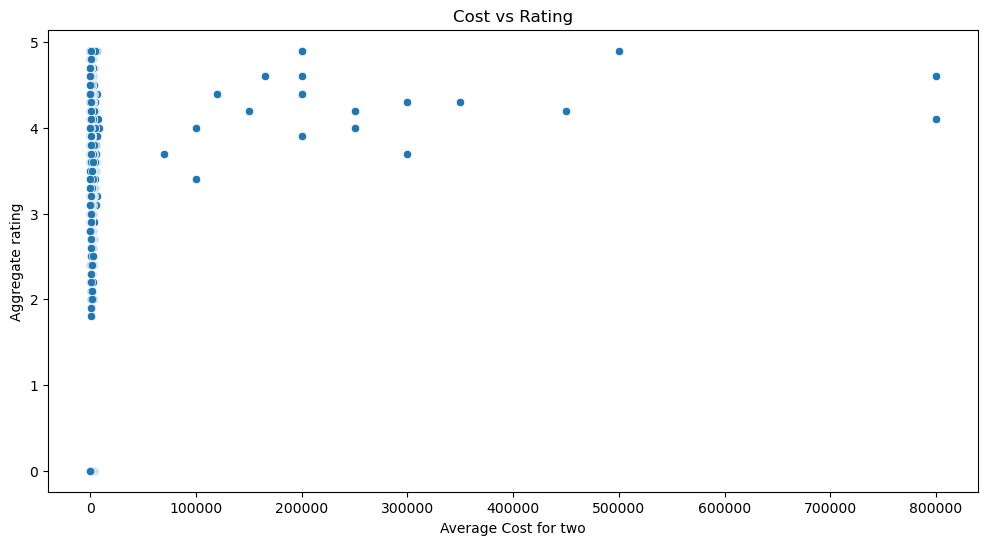

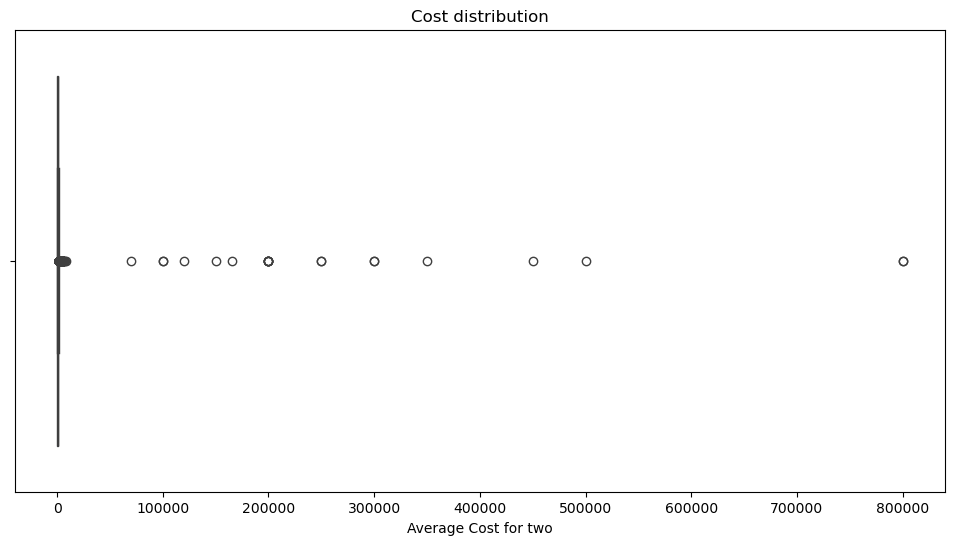

In [113]:
#Task 8: Cost Analysis
print("\nAverage cost:")
print(df["Average Cost for two"].mean())

print("\nMost expensive restaurants")
print(
    df[["Restaurant Name","City","Average Cost for two"]]
    .sort_values("Average Cost for two", ascending=False)
    .head(10)
)
#Scatterplot 
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x="Average Cost for two",
    y="Aggregate rating"
)
plt.title("Cost vs Rating")
plt.show()
print()
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x=df["Average Cost for two"])
plt.title("Cost distribution")
plt.show()

                      Longitude  Latitude  Average Cost for two  Price range  \
Longitude              1.000000  0.043207              0.045891    -0.078939   
Latitude               0.043207  1.000000             -0.111088    -0.166688   
Average Cost for two   0.045891 -0.111088              1.000000     0.075083   
Price range           -0.078939 -0.166688              0.075083     1.000000   
Aggregate rating      -0.116818  0.000516              0.051792     0.437944   
Votes                 -0.085101 -0.022962              0.067783     0.309444   

                      Aggregate rating     Votes  
Longitude                    -0.116818 -0.085101  
Latitude                      0.000516 -0.022962  
Average Cost for two          0.051792  0.067783  
Price range                   0.437944  0.309444  
Aggregate rating              1.000000  0.313691  
Votes                         0.313691  1.000000  


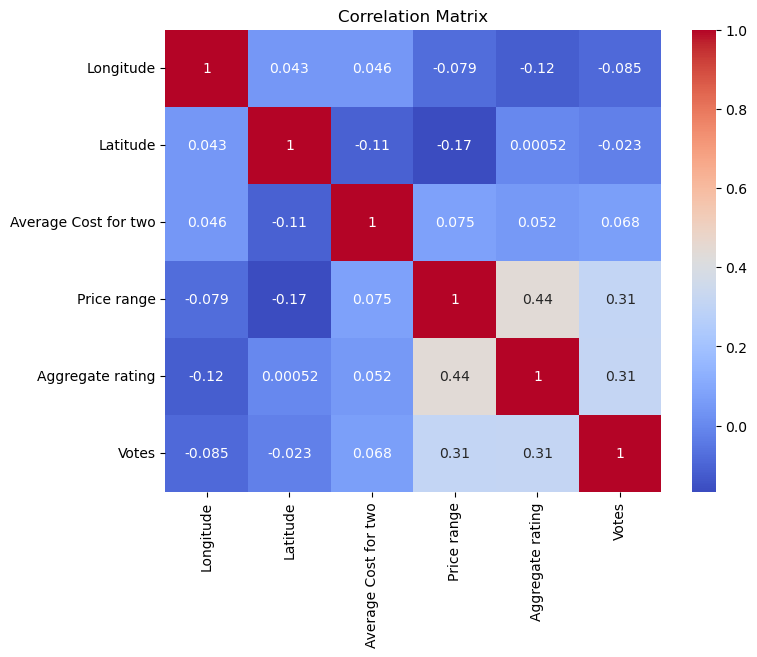

In [114]:
#Task 9: Correlation Analysis
corr_cols = [
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]
corr_matrix = df[corr_cols].corr() #Using a list to correlate values with each other
print(corr_matrix)
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

The strongest relationships are Price Range and Aggregate Rating (0.44), Price Range and Votes (0.31), Aggregate Rating and Votes (0.31) respectively.

In [115]:
#Task 10: Feature Engineering
df["Cost Category"] = pd.cut(
    df["Average Cost for two"],
    bins=[0,500,1500,4000,np.inf],
    labels=["Budget","Moderate","Premium","Luxury"] 
    #Less than 500 is Budget, less than 1500 is Moderate, Less than 4000 is Premium, 4000 or more is Luxury
)

df["Rating Category"] = pd.cut(
    df["Aggregate rating"],
    bins=[0,2.5,3.5,4.5,5],
    labels=["Poor","Average","Good","Excellent"]
    #Less than 2.5 rating is poor, Less than 3.5 rating is average, Less than 4.5 rating is Good, 4.5 rating or more is Excellent
)

print(df["Cost Category"].value_counts(),"\n")
print(df["Rating Category"].value_counts())

Cost Category
Budget      6056
Moderate    2893
Premium      521
Luxury        63
Name: count, dtype: int64 

Rating Category
Average      4107
Good         2794
Poor          296
Excellent     206
Name: count, dtype: int64


In [116]:
#Task 11: Business Insights
print("Business Insights:")
print("1. A small number of cities contribute a large percentage of restaurant listings.")
print("2. Online delivery restaurants generally receive higher ratings.")
print("3. Popular cuisines dominate restaurant distribution.")
print("4. Higher vote counts are positively associated with higher ratings.")
print("5. Extremely expensive restaurants are not always the highest rated.\n")
print("Recommendations:")
print("1. Expand delivery partnerships in cities where ratings are already strong.")
print("2. Promote high-rated niche cuisines which less people order to diversify customer demand.")
print("3. Prioritize marketing for restaurants with high ratings but low votes.")

Business Insights:
1. A small number of cities contribute a large percentage of restaurant listings.
2. Online delivery restaurants generally receive higher ratings.
3. Popular cuisines dominate restaurant distribution.
4. Higher vote counts are positively associated with higher ratings.
5. Extremely expensive restaurants are not always the highest rated.

Recommendations:
1. Expand delivery partnerships in cities where ratings are already strong.
2. Promote high-rated niche cuisines which less people order to diversify customer demand.
3. Prioritize marketing for restaurants with high ratings but low votes.
